# 라이브러리

In [4]:
import pandas as pd
import numpy as np
import os
import seaborn as sns

# 데이터 확인

In [5]:
df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

# Date + Time을 합쳐서 datetime 컬럼 생성
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

# 원래 Date, Time 컬럼은 제거 (선택 사항)
df = df.drop(columns=["Date", "Time"])

print(df.shape)
df.head()

(2075259, 8)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


## 결측치 확인

In [6]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
datetime                     0
dtype: int64

### 해석

+ 1440은 하루가 통째로 빈 날(24시간 x 60분)
    + 2007-04-29, 2009-06-14, 2010-01-13, 2010-08-18~21, 2010-09-26~27
    + 랜덤하게 여기저기 흩어진 결측이 아니라 연속된 블록 단위로 통째로 빠짐

+ 연속된 날짜들이 뭉쳐 있는 경우
    + 2010-08-18, 19, 20, 21, 22 는 5일 연속으로 결측
    + 2010-09-25, 26, 27, 28 은 4일 연속 결측

In [7]:
missing_mask = df["Global_active_power"].isnull()
df[missing_mask]["datetime"].dt.date.value_counts().head(20)

datetime
2007-04-29    1440
2009-06-14    1440
2010-01-13    1440
2010-08-18    1440
2010-08-19    1440
2010-08-20    1440
2010-08-21    1440
2010-09-26    1440
2010-09-27    1440
2007-04-28    1419
2009-06-13    1410
2010-08-22    1288
2010-03-20    1208
2010-09-25    1204
2010-09-28    1153
2010-01-14    1142
2009-08-13     891
2007-04-30     864
2010-03-21     819
2010-01-12     547
Name: count, dtype: int64

### 해석

+ 짧은 결측(1~3분)
    + 54개
    + 순간적인 통신 끊김/노이즈
    + 선형보간

+ 긴 결측(수 시간 ~ 5일)
    + 소수(약 17개)
    + 스마트미터 고장/점검 예상
    + 구간을 제외하거나 별도 플래그 처리

In [8]:
# 결측 블록 길이 분포 확인 (연속된 결측이 몇 분/몇 시간짜리가 몇 개인지)
df["is_missing"] = df["Global_active_power"].isnull()
df["missing_group"] = (df["is_missing"] != df["is_missing"].shift()).cumsum()
missing_blocks = df[df["is_missing"]].groupby("missing_group").size()

print(missing_blocks.describe())
print(missing_blocks.value_counts().head(10))

count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
dtype: float64
1       38
2       14
3        2
3723     1
33       1
83       1
47       1
21       1
43       1
6        1
Name: count, dtype: int64


In [9]:
# 긴 결측 블록만 따로 확인 (예: 60분 이상)
long_missing = missing_blocks[missing_blocks >= 60].sort_values(ascending=False)
print(long_missing)

missing_group
138    7226
140    5237
14     3723
100    3305
118    3129
126    2027
104     891
32       83
78       70
dtype: int64


### 결측치 결론

+ missing_group(긴 결측 블록)의 합계 : 25,691분
+ 전체 결측치 : 25,979개


+ 긴 결측 블록 9개가 전체 결측의 약 98.9% 차지
+ 나머지 62개 블록(1~3분)은 겨우 1.1%

+ 9번의 대형 장애 사건 + 그 외 작은 순간 끊김

In [10]:
# 각 missing_group의 시작/종료 시각 확인
long_groups = [138, 140, 14, 100, 118, 126, 104, 32, 78]

for g in long_groups:
    block = df[df["missing_group"] == g]
    start = block["datetime"].min()
    end = block["datetime"].max()
    duration = block.shape[0]
    print(f"그룹 {g}: {start} ~ {end} ({duration}분, 약 {duration/60/24:.1f}일)")

그룹 138: 2010-08-17 21:02:00 ~ 2010-08-22 21:27:00 (7226분, 약 5.0일)
그룹 140: 2010-09-25 03:56:00 ~ 2010-09-28 19:12:00 (5237분, 약 3.6일)
그룹 14: 2007-04-28 00:21:00 ~ 2007-04-30 14:23:00 (3723분, 약 2.6일)
그룹 100: 2009-06-13 00:30:00 ~ 2009-06-15 07:34:00 (3305분, 약 2.3일)
그룹 118: 2010-01-12 14:53:00 ~ 2010-01-14 19:01:00 (3129분, 약 2.2일)
그룹 126: 2010-03-20 03:52:00 ~ 2010-03-21 13:38:00 (2027분, 약 1.4일)
그룹 104: 2009-08-13 05:00:00 ~ 2009-08-13 19:50:00 (891분, 약 0.6일)
그룹 32: 2007-07-15 16:49:00 ~ 2007-07-15 18:11:00 (83분, 약 0.1일)
그룹 78: 2008-12-10 10:48:00 ~ 2008-12-10 11:57:00 (70분, 약 0.0일)


## 짧은 결측치 처리
+ 선형보간

In [11]:
# 결측 블록 크기를 각 행에 표시
group_sizes = df.groupby("missing_group").size()
df["missing_block_size"] = df["missing_group"].map(group_sizes)

In [12]:
# 필요한 숫자 컬럼 목록 정의
numeric_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

In [13]:
# 짧은 결측 / 긴 결측 구분 플래그 만들기
df["short_missing"] = df["is_missing"] & (df["missing_block_size"] <= 5)
df["long_missing"] = df["is_missing"] & (df["missing_block_size"] > 5)

In [14]:
# 짧은 결측만 선형보간으로 채우는 함수
def preprocess_missing(df, numeric_cols):
    df = df.copy()
    for col in numeric_cols:
        mask = df["short_missing"]
        df.loc[mask, col] = df[col].interpolate(method="linear")[mask]
    return df

In [15]:
# 함수 호출 후 반환값을 df에 재할당
df = preprocess_missing(df, numeric_cols)

In [16]:
print(df[df["short_missing"]][numeric_cols].isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## 긴 결측 처리
+ 긴 결측 구간을 삭제하지 않고 그대로 NaN으로 남긴 다음 구간 플래그만 유지

In [17]:
# 긴 결측 구간(long_missing)은 삭제하지 않고 NaN 그대로 유지
# → 시계열 인덱스(datetime) 연속성을 보존하고, 이후 분석/모델링 단계에서
#    필요에 따라 구간을 제외하거나 포함할 수 있도록 플래그만 남겨둠

# 최종 결측치 현황 확인
print("전체 결측치 개수:", df[numeric_cols].isnull().sum().sum())
print()
print("short_missing (처리 완료, 0이어야 정상):")
print(df[df["short_missing"]][numeric_cols].isnull().sum())
print()
print("long_missing (의도적으로 남겨둔 결측):")
print(df[df["long_missing"]][numeric_cols].isnull().sum())

전체 결측치 개수: 181321

short_missing (처리 완료, 0이어야 정상):
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

long_missing (의도적으로 남겨둔 결측):
Global_active_power      25903
Global_reactive_power    25903
Voltage                  25903
Global_intensity         25903
Sub_metering_1           25903
Sub_metering_2           25903
Sub_metering_3           25903
dtype: int64


In [18]:
# 긴 결측 구간이 포함된 날짜 목록 (나중에 일별 집계 시 참고용)
long_missing_dates = df[df["long_missing"]]["datetime"].dt.date.unique()
print("긴 결측이 발생한 날짜:")
for d in sorted(long_missing_dates):
    print(d)

긴 결측이 발생한 날짜:
2007-04-28
2007-04-29
2007-04-30
2007-06-09
2007-07-15
2007-08-01
2008-10-25
2008-11-10
2008-12-10
2009-02-01
2009-02-17
2009-06-13
2009-06-14
2009-06-15
2009-08-13
2010-01-12
2010-01-13
2010-01-14
2010-03-20
2010-03-21
2010-08-17
2010-08-18
2010-08-19
2010-08-20
2010-08-21
2010-08-22
2010-09-25
2010-09-26
2010-09-27
2010-09-28


In [19]:
# 전처리 완료된 데이터 저장 (다음 단계 노트북에서 바로 불러다 쓰기 위함)
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/power_consumption_cleaned.csv", index=False)

print("저장 완료:", df.shape)

저장 완료: (2075259, 13)


# 정상 패턴 EDA

In [20]:
# 기본 통계량 확인
print(df[numeric_cols].describe())

       Global_active_power  Global_reactive_power       Voltage  \
count         2.049356e+06           2.049356e+06  2.049356e+06   
mean          1.091645e+00           1.237169e-01  2.408398e+02   
std           1.057324e+00           1.127237e-01  3.239989e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.940000e-01  2.428900e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count      2.049356e+06    2.049356e+06    2.049356e+06    2.049356e+06  
mean       4.627889e+00    1.121981e+00    1.298590e+00    6.458515e+00  
std        4.444523e+00    6.153206e+00    5.822073e+00    8.437165e+00  
min        2.000000e-01    0.000000e+00    0.000000e+00    0.000000e+00  
25%        1.400000e+00   

In [21]:
# 2. 시간 단위로 리샘플링 (1분 단위는 너무 세밀해서 패턴이 잘 안 보임)
df_resampled = df.set_index("datetime")[numeric_cols].resample("1h").mean()
print(df_resampled.shape)
df_resampled.head()

(34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows: 맑은 고딕 사용
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

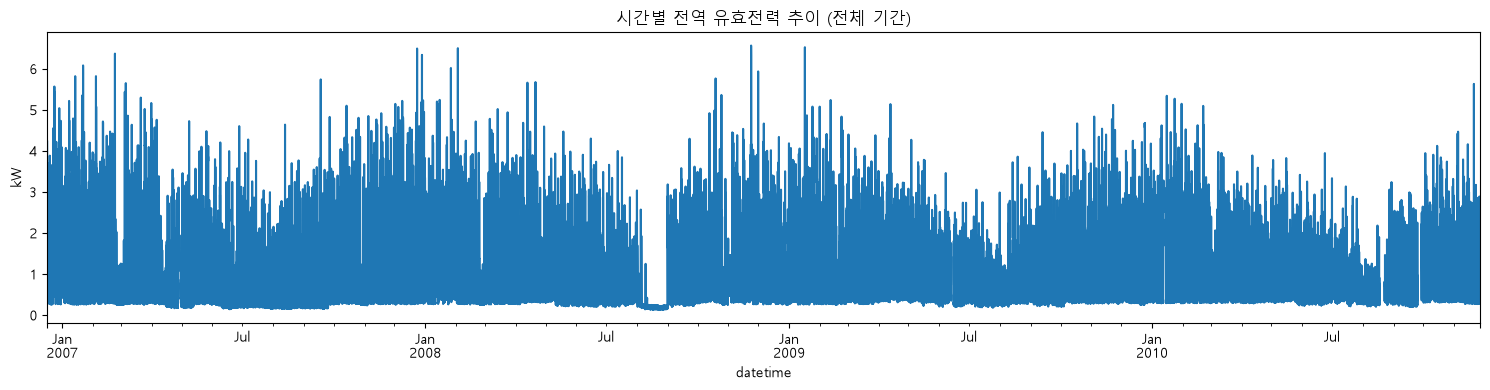

In [23]:
# 3. 전체 기간 전력 사용량 추이 시각화
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 4))
df_resampled["Global_active_power"].plot(ax=ax)
ax.set_title("시간별 전역 유효전력 추이 (전체 기간)")
ax.set_ylabel("kW")
plt.tight_layout()
plt.show()

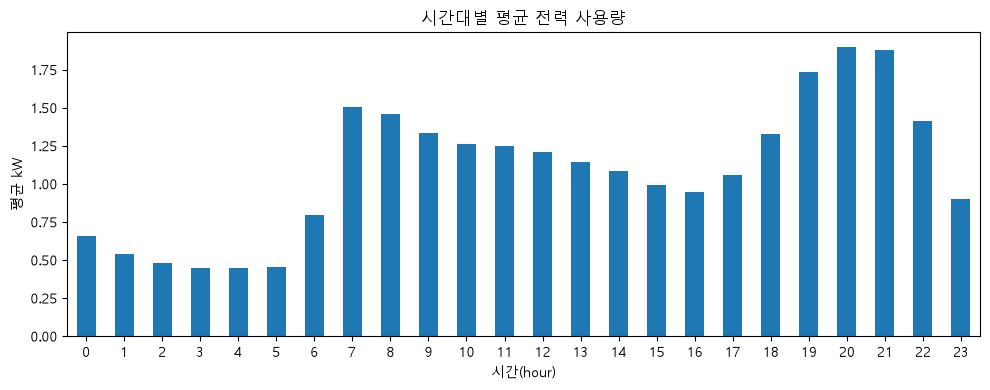

In [28]:
# 4. 하루 패턴 확인 (시간대별 평균 사용량)
df["hour"] = df["datetime"].dt.hour
hourly_pattern = df.groupby("hour")["Global_active_power"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_pattern.plot(kind="bar", ax=ax)
# x축 글씨 가로로 표시
ax.tick_params(axis='x', rotation=0)
ax.set_title("시간대별 평균 전력 사용량")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("평균 kW")
plt.tight_layout()
plt.show()

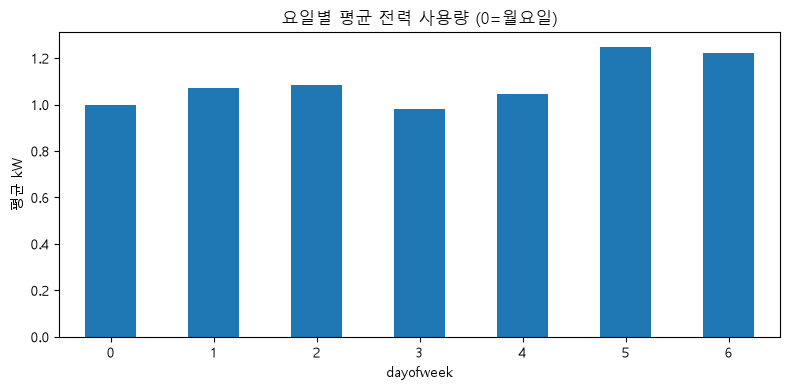

In [29]:
# 5. 요일별 패턴 확인
df["dayofweek"] = df["datetime"].dt.dayofweek  # 0=월, 6=일
daily_pattern = df.groupby("dayofweek")["Global_active_power"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
daily_pattern.plot(kind="bar", ax=ax)
# x축 글씨 가로로 표시
ax.tick_params(axis='x', rotation=0)
ax.set_title("요일별 평균 전력 사용량 (0=월요일)")
ax.set_ylabel("평균 kW")
plt.tight_layout()
plt.show()

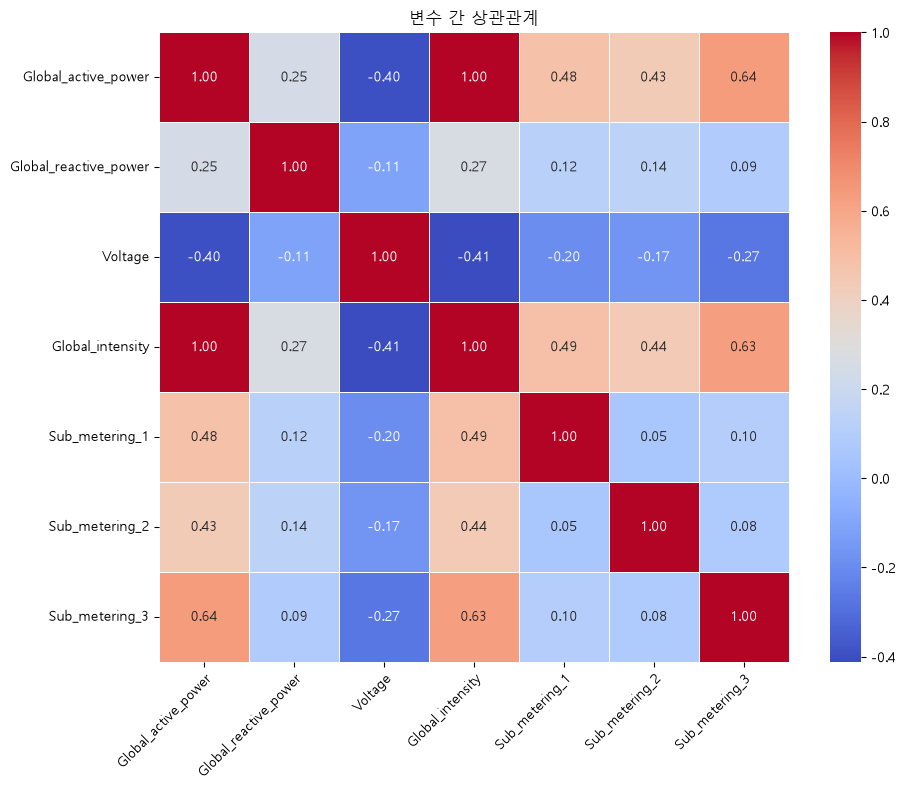

In [35]:
# 6. 변수 간 상관관계 확인
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,      # 셀을 정사각형으로
    linewidths=0.5,   # 셀 경계선
    ax=ax
)

ax.set_title("변수 간 상관관계")

# x축과 y축 레이블 정리
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

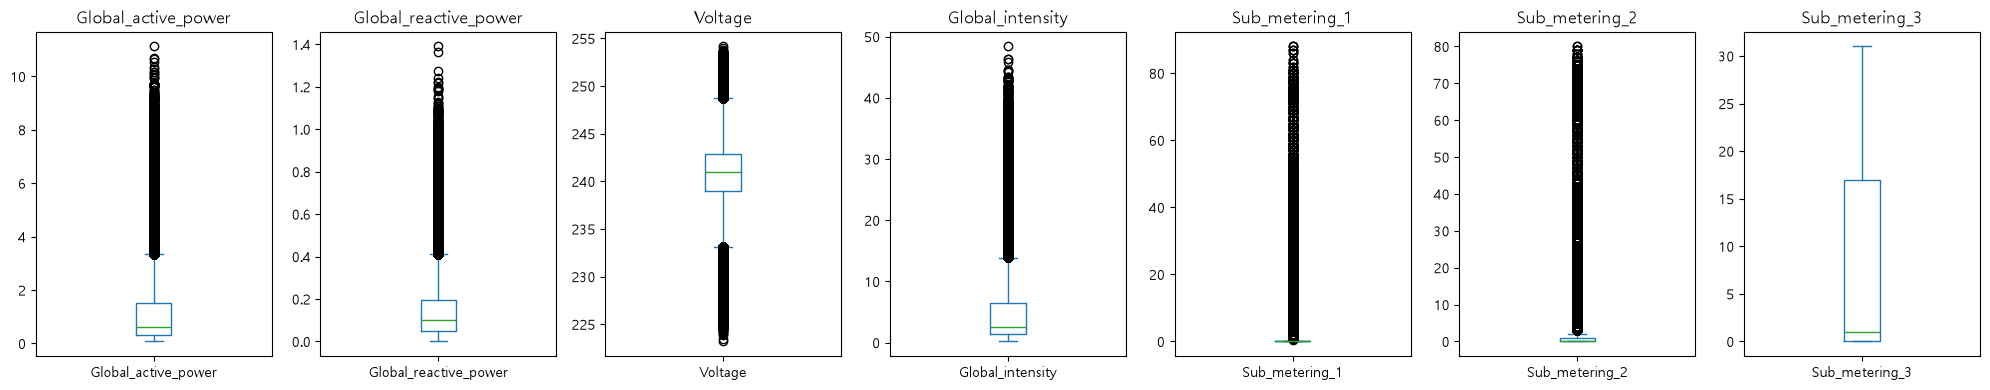

In [27]:
# 7. 극단값(outlier) 대략 확인 - boxplot
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    df[col].plot(kind="box", ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()